In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [47]:
df = pd.read_csv("dataset/retail_sales_dataset.csv")

df.head()

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,...,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,...,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,...,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,...,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.0,Male,Central,Nagpur,Groceries,Cooking Oil,...,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0


In [48]:
df.shape

(4310, 21)

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4310 entries, 0 to 4309
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               4280 non-null   str    
 1   order_date             4280 non-null   str    
 2   customer_id            4280 non-null   str    
 3   customer_name          4280 non-null   str    
 4   age                    4150 non-null   float64
 5   gender                 4280 non-null   str    
 6   region                 4280 non-null   str    
 7   city                   4280 non-null   str    
 8   product_category       4280 non-null   str    
 9   product_name           4280 non-null   str    
 10  quantity               4170 non-null   float64
 11  unit_price             4280 non-null   float64
 12  discount_pct           4143 non-null   float64
 13  sales_amount           4280 non-null   float64
 14  profit                 4280 non-null   float64
 15  shipping_cost  

In [50]:
df.isnull().sum()

order_id                  30
order_date                30
customer_id               30
customer_name             30
age                      160
gender                    30
region                    30
city                      30
product_category          30
product_name              30
quantity                 140
unit_price                30
discount_pct             167
sales_amount              30
profit                    30
shipping_cost             30
payment_method            30
customer_satisfaction    378
return_flag               30
order_status              30
days_to_ship             130
dtype: int64

In [51]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percent
})

missing_summary[missing_summary["Missing Values"] > 0].sort_values(
    by="Missing Percentage",
    ascending=False
)

,Missing Values,Missing Percentage
customer_satisfaction,378,8.770302
discount_pct,167,3.874710
age,160,3.712297
quantity,140,3.248260
days_to_ship,130,3.016241
customer_name,30,0.696056
customer_id,30,0.696056
order_date,30,0.696056
order_id,30,0.696056
product_category,30,0.696056


In [52]:
df.duplicated().sum()

np.int64(109)

In [53]:
df["order_id"].duplicated().sum()

np.int64(109)

In [54]:
df["order_date"].dtype


<StringDtype(storage='python', na_value=nan)>

In [55]:
df["order_date"] = pd.to_datetime(
    df["order_date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [56]:
df["order_date"].dtype

dtype('<M8[us]')

In [57]:
df["order_date"].isna().sum()

np.int64(30)

In [58]:
df["order_date"].min(), df["order_date"].max()

(Timestamp('2020-01-01 00:00:00'), Timestamp('2024-12-30 00:00:00'))

In [59]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["month_name"] = df["order_date"].dt.month_name()
df["quarter"] = df["order_date"].dt.quarter

df[["order_date", "year", "month", "month_name", "quarter"]].head()

,order_date,year,month,month_name,quarter
0,2024-08-15,2024.0,8.0,August,3.0
1,2022-08-16,2022.0,8.0,August,3.0
2,2021-08-29,2021.0,8.0,August,3.0
3,2022-05-07,2022.0,5.0,May,2.0
4,2020-07-05,2020.0,7.0,July,3.0


In [60]:
df.describe()

,order_date,age,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,customer_satisfaction,days_to_ship,year,month,quarter
count,4280,4150.000000,4170.000000,4280.000000,4143.000000,4.280000e+03,4.280000e+03,4280.000000,3932.000000,4180.000000,4280.000000,4280.000000,4280.000000
mean,2022-07-04 01:00:33.644859,35.335181,7.379856,10621.154428,0.202085,6.235864e+04,1.168713e+04,63.358836,3.016531,5.620335,2022.011682,6.449533,2.491822
min,2020-01-01 00:00:00,-7.000000,-1.000000,50.260000,0.000000,3.945000e+01,1.560000e+00,-4.290000,1.000000,-1.000000,2020.000000,1.000000,1.000000
25%,2021-04-10 18:00:00,26.000000,3.000000,672.222500,0.100000,2.462165e+03,7.018225e+02,50.817500,2.000000,3.000000,2021.000000,4.000000,2.000000
50%,2022-07-08 00:00:00,34.000000,5.000000,2228.435000,0.210000,9.548075e+03,3.128005e+03,63.465000,3.000000,6.000000,2022.000000,6.000000,2.000000
75%,2023-09-25 06:00:00,42.000000,8.000000,12717.435000,0.310000,5.006964e+04,1.040372e+04,75.650000,4.000000,8.000000,2023.000000,9.000000,3.000000
max,2024-12-30 00:00:00,999.000000,999.000000,79957.920000,0.400000,1.736031e+07,2.445648e+06,133.350000,5.000000,100.000000,2024.000000,12.000000,4.000000
std,NaN,35.709382,43.578352,17323.704016,0.118095,3.166998e+05,5.287522e+04,18.312281,1.413127,4.178663,1.396538,3.431400,1.111216


In [61]:
df.describe(include="object")

C:\Users\tamal\AppData\Local\Temp\ipykernel_19612\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,order_id,customer_id,customer_name,gender,region,city,product_category,product_name,payment_method,return_flag,order_status,month_name
count,4280,4280,4280,4280,4280,4280,4280,4280,4280,4280,4280,4280
unique,4200,4112,400,11,5,20,7,42,6,2,9,12
top,ORD-01505,CUST64655,Meera Kumar,Other,South,Amritsar,Clothing,Dal (1kg),UPI,False,Delivered,January
freq,2,3,21,1442,885,242,645,120,761,3657,2666,388


In [62]:
df.select_dtypes(include=np.number).columns

Index(['age', 'quantity', 'unit_price', 'discount_pct', 'sales_amount',
       'profit', 'shipping_cost', 'customer_satisfaction', 'days_to_ship',
       'year', 'month', 'quarter'],
      dtype='str')

In [63]:
df.select_dtypes(include="object").columns

C:\Users\tamal\AppData\Local\Temp\ipykernel_19612\1196084386.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['order_id', 'customer_id', 'customer_name', 'gender', 'region', 'city',
       'product_category', 'product_name', 'payment_method', 'return_flag',
       'order_status', 'month_name'],
      dtype='str')

In [64]:
monthly_sales = df.groupby(
    df["order_date"].dt.to_period("M")
)["sales_amount"].sum()

monthly_sales.head()

order_date
2020-01    3330147.37
2020-02    2587975.88
2020-03    2700283.75
2020-04    3441862.90
2020-05    5198645.81
Freq: M, Name: sales_amount, dtype: float64

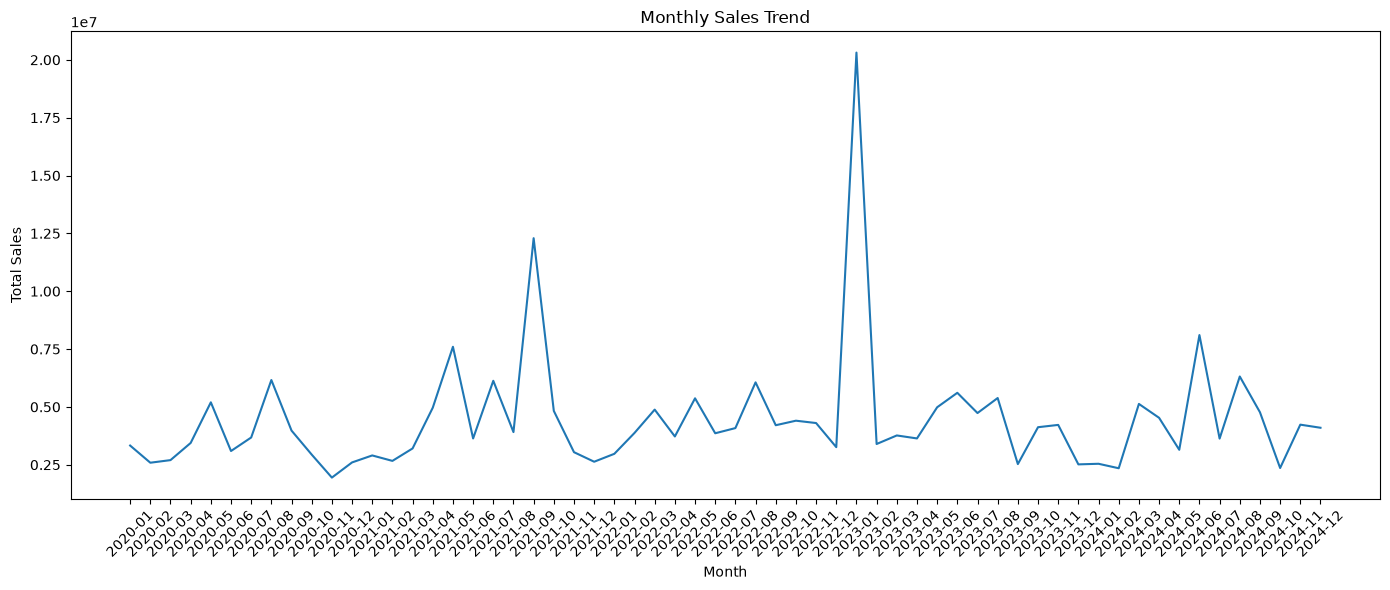

In [65]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Observation: Monthly Sales Trend – Observations

- Monthly sales show significant fluctuations throughout the 2020–2024 period.
- A prominent sales spike is observed around December 2022, which is substantially higher than the surrounding months.
- Several smaller peaks occur across 2021, 2023, and 2024, indicating periods of stronger sales activity.
- The unusually high December 2022 value should be investigated further to determine whether it is driven by specific products, categories, customers, or transactions.

In [66]:
quarterly_sales = df.groupby(
    df["order_date"].dt.to_period("Q")
)["sales_amount"].sum()

quarterly_sales.head()

order_date
2020Q1     8618407.00
2020Q2    11734258.41
2020Q3    13816703.56
2020Q4     7484818.32
2021Q1     8774970.38
Freq: Q-DEC, Name: sales_amount, dtype: float64

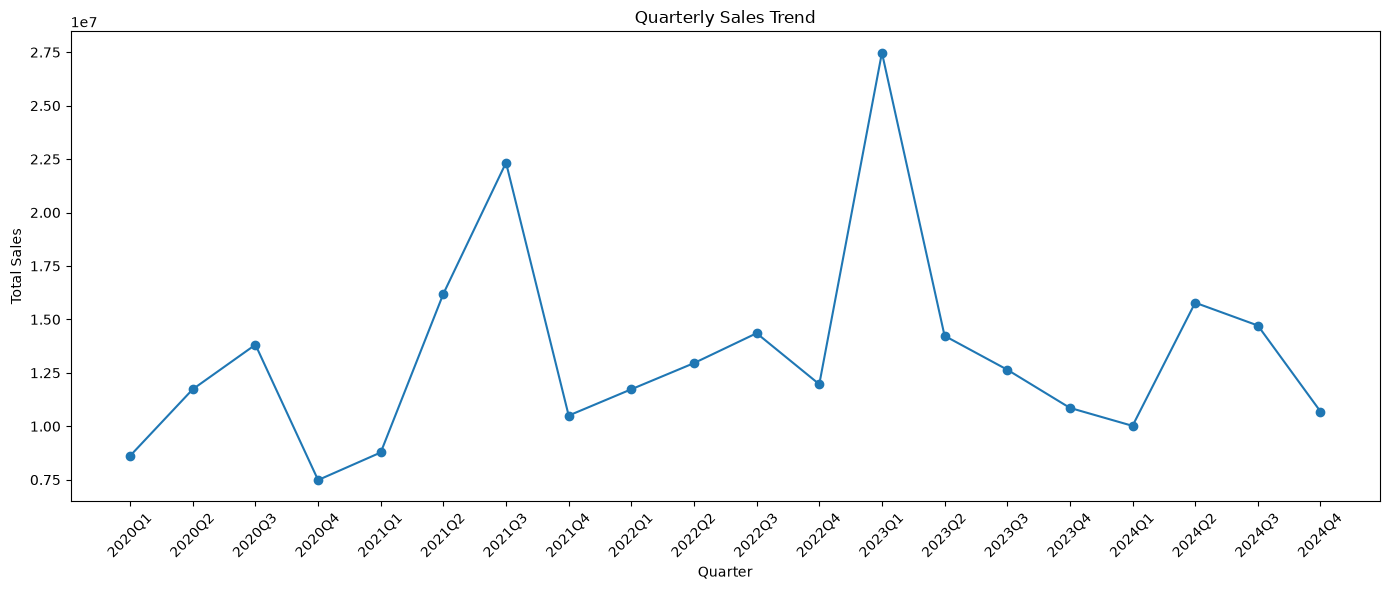

In [67]:
plt.figure(figsize=(14, 6))

plt.plot(
    quarterly_sales.index.astype(str),
    quarterly_sales.values,
    marker="o"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Quarterly Sales Trend – Observations

- Quarterly sales fluctuate considerably throughout the 2020–2024 period.
- Q1 2023 records the highest quarterly sales in the dataset.
- Q2 2021 also shows a strong sales peak compared with the surrounding quarters.
- Several years show a decline in sales during Q4, although the pattern is not perfectly consistent.
- The strong performance in Q1 2023 should be investigated further by examining product categories, products, regions, and customer segments.

In [68]:
df["age"].describe()    

count    4150.000000
mean       35.335181
std        35.709382
min        -7.000000
25%        26.000000
50%        34.000000
75%        42.000000
max       999.000000
Name: age, dtype: float64

In [69]:
df.loc[df["age"] > 100, ["customer_id", "customer_name", "age"]]

,customer_id,customer_name,age
44,CUST29818,Meera Gupta,999.0
148,CUST44662,Ananya Nair,999.0
466,CUST12279,Meera Patel,999.0
1010,CUST52922,Vikram Shah,999.0
1411,CUST04245,Sanjay Iyer,150.0
2265,CUST26263,Arjun Singh,150.0
3865,CUST90788,Kavya Kapoor,999.0
4168,CUST01982,Meera Rao,150.0


In [70]:
df["age_clean"] = df["age"].where(
    df["age"].between(1, 100)
)

df["age_clean"].isna().sum()

np.int64(186)

In [71]:
df["age_clean"].describe()

count    4124.000000
mean       34.250727
std        11.825073
min         1.000000
25%        26.000000
50%        34.000000
75%        42.000000
max        72.000000
Name: age_clean, dtype: float64

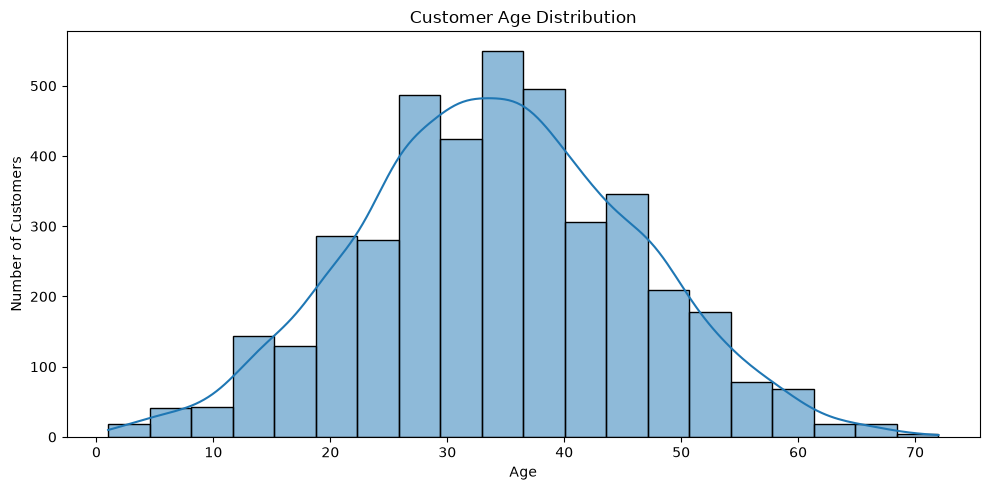

In [72]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="age_clean",
    bins=20,
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.show()

Customer Age Distribution – Observations

- Customer ages are concentrated mainly between approximately 20 and 50 years.
- The distribution is centered around the mid-30s, consistent with the mean age of approximately 34.2 years.
- Customers in the 30–40 age range represent a major portion of the dataset.
- The number of customers decreases progressively at older ages, with relatively fewer customers above 50.
- Extreme age values identified during the initial data-quality check were excluded from this analytical visualization.

In [73]:
df["age_clean"] = df["age"].where(
    df["age"].between(1, 100)
)

In [74]:
df["age_clean"].isna().sum()

np.int64(186)

In [75]:
df["age_clean"].describe()

count    4124.000000
mean       34.250727
std        11.825073
min         1.000000
25%        26.000000
50%        34.000000
75%        42.000000
max        72.000000
Name: age_clean, dtype: float64

In [76]:
gender_map = {
    "male": "Male",
    "m": "Male",
    "female": "Female",
    "f": "Female",
    "other": "Other"
}

df["gender_clean"] = (
    df["gender"]
    .str.strip()
    .str.lower()
    .map(gender_map)
)

In [77]:
df["gender_clean"].value_counts(dropna=False)

gender_clean
Other     1442
Male      1442
Female    1396
NaN         30
Name: count, dtype: int64

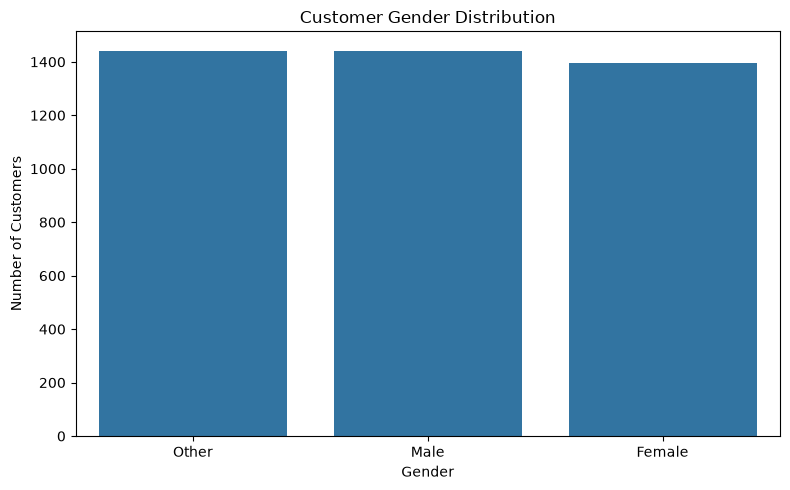

In [78]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="gender_clean",
    order=df["gender_clean"].value_counts().index
)

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()

plt.show()

In [79]:
gender_sales = df.groupby("gender_clean")["sales_amount"].sum().sort_values(
    ascending=False
)

gender_sales

gender_clean
Male      93749742.36
Other     86724723.24
Female    86420503.41
Name: sales_amount, dtype: float64

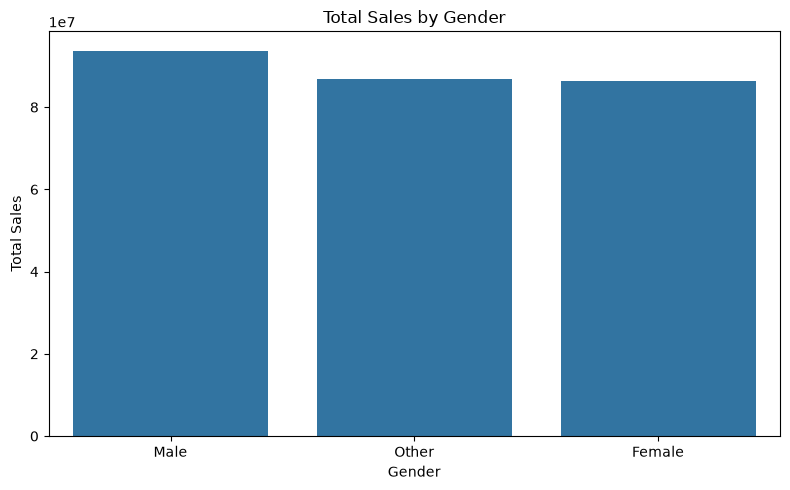

In [80]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=gender_sales.index,
    y=gender_sales.values
)

plt.title("Total Sales by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

### Gender-wise Sales – Observations

- Male customers generated the highest total sales among the three gender categories.
- Customers classified as Other contributed the second-highest total sales.
- Female customers generated slightly lower total sales compared with Male and Other customers.
- The difference in total sales across the gender categories is relatively small, indicating that sales are fairly distributed across customer groups.
- Businesses can consider maintaining inclusive marketing strategies rather than focusing only on a single gender category.

In [81]:
df["age_group"] = pd.cut(
    df["age_clean"],
    bins=[0, 18, 25, 35, 45, 55, 65, 100],
    labels=["Under 18", "18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
)

df["age_group"].value_counts().sort_index()

age_group
Under 18     376
18-25        566
26-35       1317
36-45       1119
46-55        589
56-65        141
66+           16
Name: count, dtype: int64

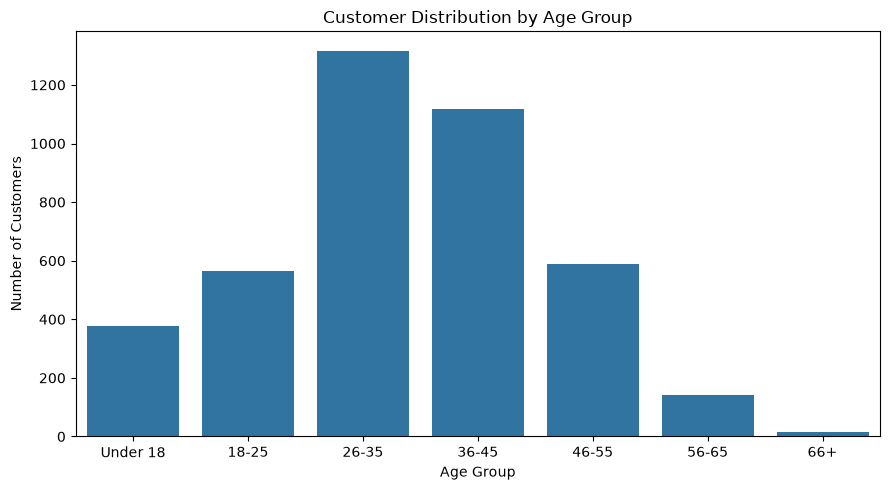

In [82]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="age_group",
    order=df["age_group"].cat.categories
)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Customer Age Group – Observations

- The 26–35 age group has the highest number of customers, with 1,317 customers.
- The 36–45 age group is the second-largest segment, with 1,119 customers.
- Customers aged 18–25 and 46–55 have relatively similar representation.
- The 56–65 and 66+ age groups have comparatively fewer customers.
- Overall, the customer base is concentrated mainly in the 26–45 age range.
- The business can focus targeted marketing campaigns and product offers toward customers aged 26–45 while maintaining strategies for other age segments.

In [83]:
top_10_products = (
    df.groupby("product_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_10_products

product_name
Rice (5kg)        1568.0
Jeans             1563.0
Tennis Racket     1524.0
Jacket            1522.0
Fiction Novel     1519.0
Cook Book         1494.0
Self-Help Book    1483.0
Tablet            1470.0
Desk               656.0
Laptop             655.0
Name: quantity, dtype: float64

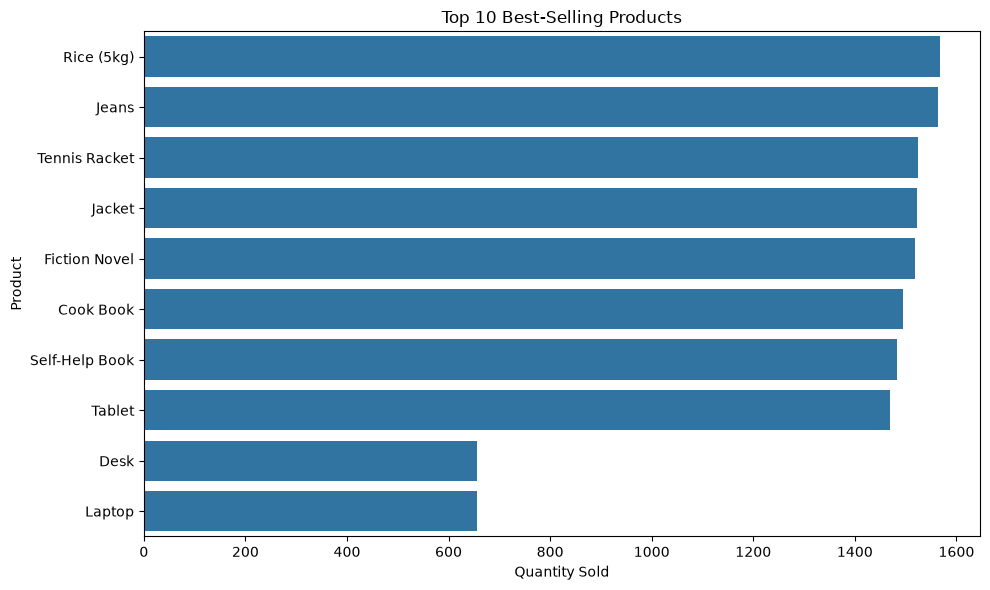

In [84]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_products.values,
    y=top_10_products.index
)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    "outputs/top_10_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Top 10 Best-Selling Products – Observations

- Rice (5kg) recorded the highest quantity sold, with 1,568 units.
- Jeans ranked second with 1,563 units sold.
- Tennis Racket and Jacket also showed strong sales volume, with 1,524 and 1,522 units respectively.
- The top eight products have relatively similar sales volumes, ranging from 1,470 to 1,568 units.
- Desk and Laptop recorded substantially lower quantities compared with the other top-selling products.
- The business can monitor inventory levels of high-volume products to reduce the risk of stockouts and evaluate the lower-volume products for pricing or promotional opportunities.

In [85]:
category_revenue = (
    df.groupby("product_category")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

product_category
Electronics    1.571703e+08
Furniture      5.713040e+07
Sports         3.209245e+07
Clothing       1.167328e+07
Beauty         3.967541e+06
Books          3.824242e+06
Groceries      1.036782e+06
Name: sales_amount, dtype: float64

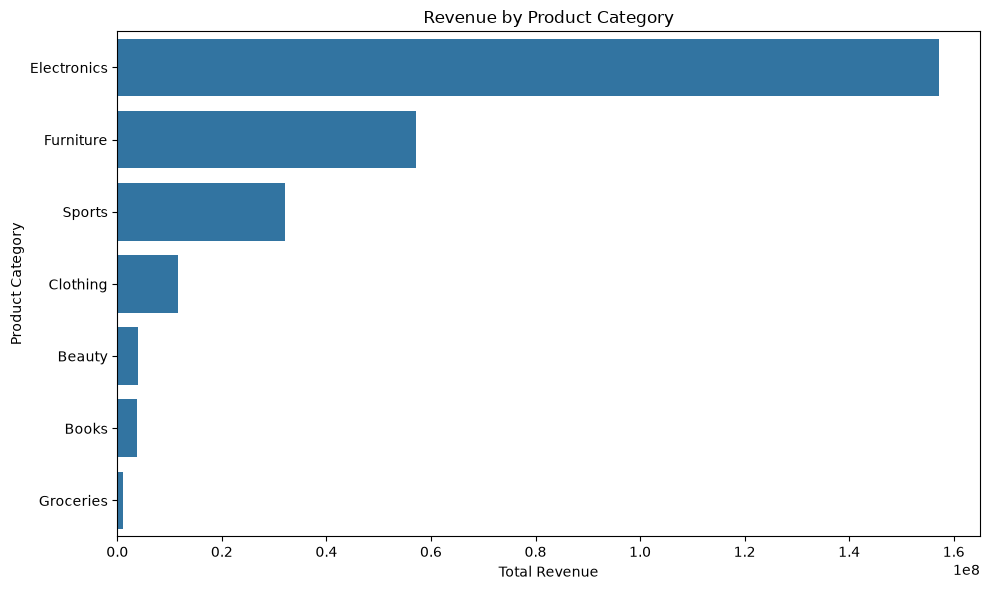

In [86]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index
)

plt.title("Revenue by Product Category")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")

plt.tight_layout()

plt.savefig(
    "outputs/revenue_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Revenue by Product Category – Observations

- Electronics generated the highest revenue, with approximately 157.17 million in total sales.
- Furniture generated the second-highest revenue at approximately 57.13 million.
- Sports contributed approximately 32.09 million in revenue.
- Clothing generated approximately 11.67 million, while Beauty and Books generated around 3.97 million and 3.82 million respectively.
- Groceries recorded the lowest revenue among the product categories, at approximately 1.04 million.
- The revenue distribution is highly concentrated in Electronics, followed by Furniture and Sports.
- The business can prioritize inventory planning for high-revenue categories while reviewing pricing, promotions, and product assortment for lower-revenue categories.

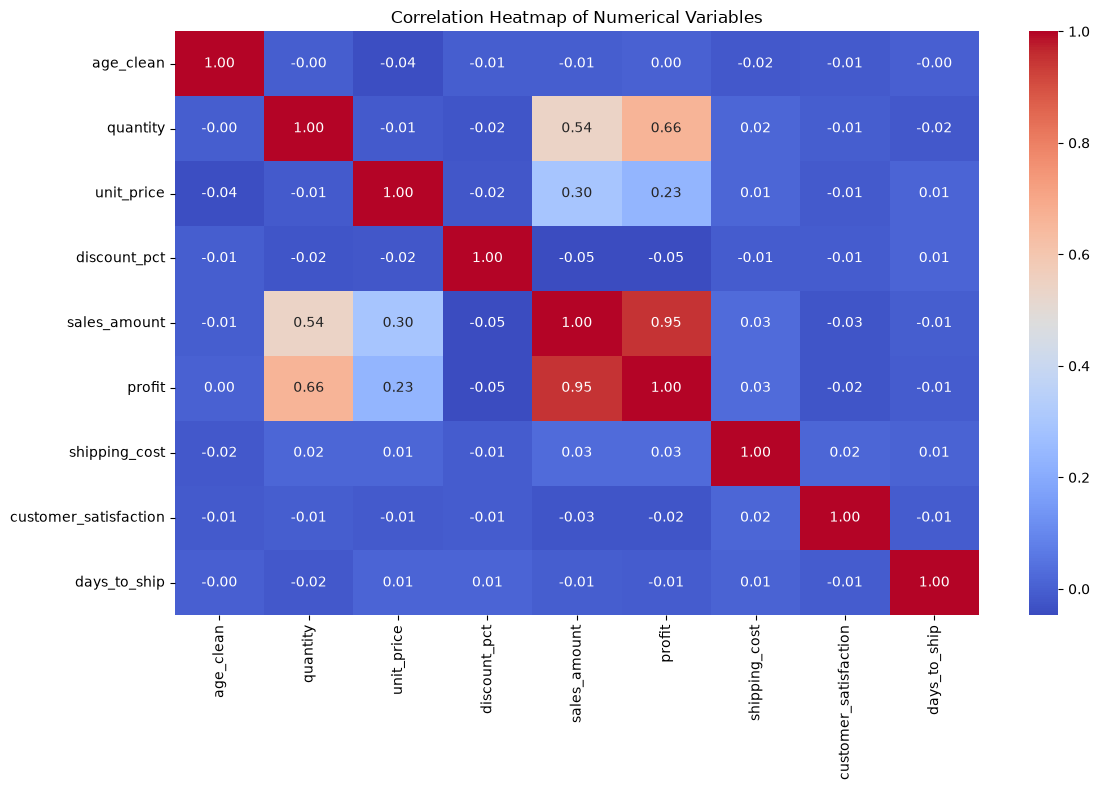

In [87]:
# Correlation Heatmap

numerical_cols = [
    "age_clean",
    "quantity",
    "unit_price",
    "discount_pct",
    "sales_amount",
    "profit",
    "shipping_cost",
    "customer_satisfaction",
    "days_to_ship"
]

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()

plt.savefig(
    "outputs/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Correlation Heatmap – Observations

- Sales Amount and Profit show a very strong positive correlation.
- Quantity has a positive relationship with both Sales Amount and Profit.
- Unit Price has a moderate positive relationship with Sales Amount.
- Discount Percentage shows a weak relationship with Sales Amount and Profit.
- Age, shipping cost, customer satisfaction, and days to ship show relatively weak linear relationships with Sales Amount and Profit.
- Correlation indicates association between variables and does not by itself establish causation.

In [88]:
category_profitability = (
    df.groupby("product_category")
      .agg(
          total_sales=("sales_amount", "sum"),
          total_profit=("profit", "sum")
      )
)

category_profitability["profit_margin"] = (
    category_profitability["total_profit"]
    / category_profitability["total_sales"]
) * 100

category_profitability = category_profitability.sort_values(
    "profit_margin",
    ascending=False
)

category_profitability

,total_sales,total_profit,profit_margin
product_category,,,
Beauty,3.967541e+06,1792922.71,45.189775
Books,3.824242e+06,1424006.08,37.236297
Clothing,1.167328e+07,4212780.97,36.089106
Furniture,5.713040e+07,16134849.68,28.242144
Sports,3.209245e+07,7079357.54,22.059261
Electronics,1.571703e+08,19295549.67,12.276844
Groceries,1.036782e+06,81428.58,7.853972


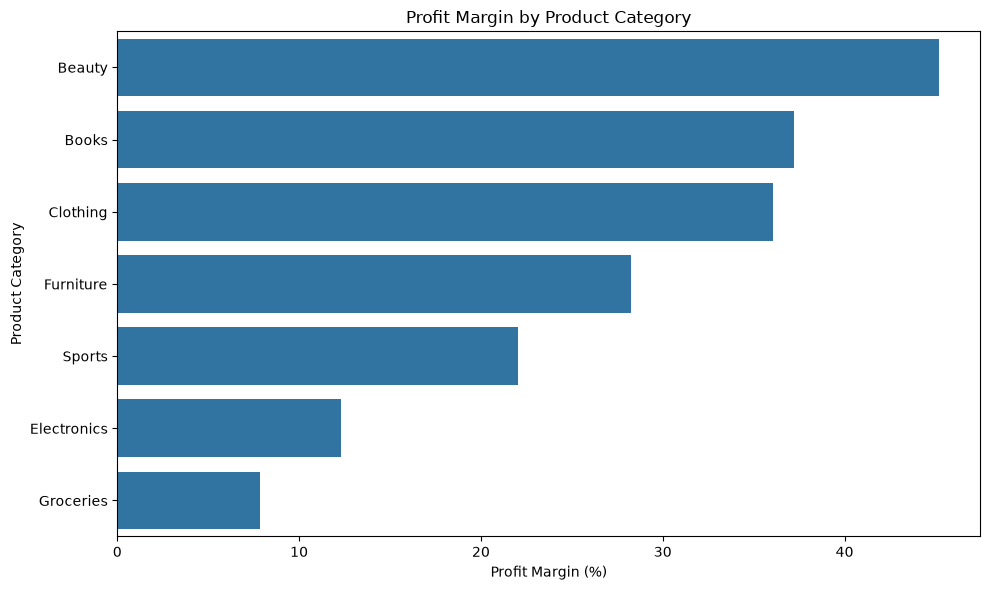

In [89]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_profitability["profit_margin"],
    y=category_profitability.index
)

plt.title("Profit Margin by Product Category")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Product Category")

plt.tight_layout()

plt.savefig(
    "outputs/profit_margin_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Profit Margin by Product Category – Observations

- Beauty has the highest profit margin at approximately 45.19%.
- Books and Clothing also show relatively high profit margins of approximately 37.24% and 36.09%, respectively.
- Furniture has a profit margin of approximately 28.24%, followed by Sports at approximately 22.06%.
- Electronics generates the highest total sales in the dataset, but its profit margin is comparatively lower at approximately 12.28%.
- Groceries has the lowest profit margin at approximately 7.85%.
- The analysis shows that a category with high revenue does not necessarily have the highest profit margin.
- Profit margin can be used alongside total revenue and total profit to evaluate category-level business performance.

## Conclusion

The exploratory data analysis provided insights into sales trends, customer demographics, product performance, category-level revenue, and profitability.

Sales showed fluctuations across different months and quarters, indicating that sales performance varied over time. The customer base was mainly concentrated in the 26–45 age range, with the 26–35 group representing the largest age segment.

Rice (5kg), Jeans, Tennis Racket, and Jacket were among the highest-selling products by quantity. At the category level, Electronics generated the highest total sales, followed by Furniture and Sports.

The profitability analysis revealed that high revenue does not necessarily mean high profit margin. Electronics generated the highest sales but had a profit margin of approximately 12.28%, while Beauty had the highest profit margin at approximately 45.19%.

The correlation analysis showed a very strong positive relationship between sales amount and profit (0.95), along with positive relationships between quantity and profit (0.66) and quantity and sales amount (0.54).

Overall, the analysis can help the business improve inventory planning, customer targeting, category-level strategy, and profitability monitoring.

## Actionable Business Recommendations

1. **Optimize inventory for high-volume products**
   - Maintain adequate stock levels for products with consistently high sales quantities, such as Rice (5kg), Jeans, Tennis Racket, and Jacket, to reduce the risk of stockouts.

2. **Review Electronics profitability**
   - Electronics generates the highest revenue but has a comparatively low profit margin of 12.28%. The business should review pricing, discounts, sourcing costs, and product-level margins within this category.

3. **Target the core customer age groups**
   - Since customers aged 26–45 form the largest customer segment, targeted promotions and product recommendations can be designed for this age range while continuing to serve other customer groups.

4. **Focus on both revenue and margin**
   - Category decisions should consider total sales, total profit, and profit margin together rather than relying only on revenue. High-margin categories such as Beauty, Books, and Clothing can be evaluated for opportunities to expand their contribution.